# Instance Segmentation with Mask Region Based Convolutional Neural Network.

You would have seen in our previous posts that Convolutional Neural Network
for computer vision task like

- [Image classification](https://www.learnopencv.com/pytorch-for-beginners-image-classification-using-pre-trained-models/)

- [Semantic Segmentation](https://www.learnopencv.com/pytorch-for-beginners-semantic-segmentation-using-torchvision/)

- [Object Detection](https://www.learnopencv.com/faster-r-cnn-object-detection-with-pytorch/)

In this notebook we will look at another computer vision application called Instance Segmentation.

## Table of Contents
* [1. What is an Instance Segmentation?](#1.-What-is-an-Instance-Segmentation)
* [2. Instance Segmentation with Torchvision Models](#2.-Instance-Segmentation-with-Torchvision-Models)
* [3. Inference](#3.-Inference)
* [4. Comparing the inference time of model in CPU & GPU](#4.-Comparing-the-inference-time-of-model-in-CPU-&-GPU)
* [5. Application: Background blurring](#5.-Application:-Background-blurring)
* [6. Conclusion](#6.-Conclusion)

# 1. What is an Instance Segmentation?
  Instance Segmentation is a combination of 2 problems
  - **Object Detection**
  - **Semantic Segmentation**

Instance Segmentation involves classifying each pixel or voxel of a given image or volume to a particular class and assigning a unique identity to the pixels of individual objects. Semantic Segmentation, on the other hand, also classifies each pixel of an image to a particular class, but it does not differentiate between individual objects of the same class. All pixels belonging to a single class are assigned the same label, without distinguishing between different objects.

<img src=https://learnopencv.com/wp-content/uploads/2024/04/object-vs-semantic-vs-instance_segmentation-Finetuning-YOLOv9-Instance-Segmentation-768x366.png>

This makes Instance Segmentation suitable for applications where the outline of objects, their spatial distribution matter, and individual identities. So meticulously, Instance segmentation is a combination of object detection (class-wise localization)  and segmentation (pixel-wise classification).


  
<img src="https://learnopencv.com/wp-content/uploads/2022/10/instance-segmentation.jpeg">

A kind of network called Mask RCNN is the state of the art in Instance Segmentation. **Mask RCNN** uses 2 type of networks one like Faster RCNN for Object Detection and another fully convolutional network for Semantic Segmentation. The first model will get the bounding box and classify it and the second model is used on each of the region of interest for semantic segmentation.

In brief, Faster RCNN consists of two stages. The first stage, called a Region Proposal Network (RPN), proposes candidate object bounding boxes. The second stage, which is in essence Fast R-CNN, extracts features using RoIPool from each candidate box and performs classification and bounding-box regression. Mask R-CNN adopts the same two-stage procedure, with an identical first stage (which is RPN). In the second stage, in parallel to predicting the class and box offset, Mask R-CNN also outputs a binary mask for each RoI.
  
<img src="https://learnopencv.com/wp-content/uploads/2022/10/working-of-mask-rcnn.png" width=700>

Image Source: [Mask R-CNN](https://arxiv.org/pdf/1703.06870.pdf)

### Import Dependencies

In [ ]:
# import necessary libraries
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import torchvision
import torch
import numpy as np
import cv2
import random
import time
import os
import subprocess
import requests
import glob

In [ ]:
np.random.seed(20)

# 2. Instance Segmentation with Torchvision Models

If you want to learn more about all of these models and many more application and concepts of Deep Learning and Computer Vision indetail,  check out the official [Deep Learning and Computer Vision courses](https://opencv.org/courses/) by OpenCV.org.

  All the pretrained models in pytorch can be found in [torchvision.models](https://pytorch.org/docs/stable/torchvision/models.html)



The input to the model is expected to be a list of tensors, each of shape **[C, H, W]**, one for each image, and should be in 0-1 range. Different images can have different sizes.


During inference, the model requires only the input tensors, and returns the post-processed predictions as a **List[Dict[Tensor]]**, one for each input image. The fields of the Dict are as follows:

- `boxes (Tensor [N, 4]`): the predicted boxes in **[x0, y0, x1, y1]** format, with values between 0 and H and 0 and W.

- `labels (Tensor[N]`): the predicted labels for each image.

-  `scores  (Tensor[N]`): the scores or each prediction.

-  `masks  (Tensor[N, H, W]`): the predicted masks for each instance, in 0-1 range. In order to obtain the final segmentation masks, the soft masks can be thresholded, generally with a value of 0.5 (mask >= 0.5).

## 2.1. Download the Pre-trained model

In [ ]:
# get the pretrained model from torchvision.models
# model.eval() to use the model for inference
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
)
_ = model.eval()

 # These are the classes that are available in the COCO-Dataset
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone',
    'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

COLORS = np.random.uniform(0, 255, size=(len(COCO_INSTANCE_CATEGORY_NAMES), 3))

## 2.2. Utilities

Let's create some helper functions.   
We will create the `random_color_masks()` function to fill the predicted-mask with colors, `get_predictions()` to return the final predictions from the model and finally the `instance_segmentation_api()` to overlay the colored mask over the original image and plot it.

In [ ]:
# Assign a color to each detected object mask for visualization
def random_color_masks(image, colors):
    """
    Assigns a random color to each predicted object mask.

    Parameters:
        image (numpy.ndarray): Binary mask where detected object pixels are 1.
        colors (list): List of available colors for masks.

    Returns:
        numpy.ndarray: Colored mask of the same shape as the input.
    """
    # Create empty color channels
    r, g, b = np.zeros_like(image, dtype=np.uint8), np.zeros_like(image, dtype=np.uint8), np.zeros_like(image, dtype=np.uint8)

    # Assign a random color to the mask
    r[image == 1], g[image == 1], b[image == 1] = colors[random.randint(0, len(colors) - 1)]

    # Stack the channels to create a colored mask
    return np.stack([r, g, b], axis=2)


# Get predictions (masks, bounding boxes, and class labels) from the model
def get_prediction(img_path, threshold):
    """
    Performs object instance segmentation on an image.

    Parameters:
        img_path (str): Path to the input image.
        threshold (float): Confidence threshold for filtering predictions.

    Returns:
        tuple: (masks, bounding boxes, class labels)
    """
    # Load image using PIL
    img = Image.open(img_path)

    # Convert image to a PyTorch tensor
    img_tensor = T.ToTensor()(img)

    # Perform inference with the model in no-grad mode to save memory
    with torch.no_grad():
        pred = model([img_tensor])

    # Extract predictions and convert to NumPy arrays
    pred_data = pred[0]
    scores = pred_data['scores'].detach().cpu().numpy()
    labels = pred_data['labels'].detach().cpu().numpy()
    boxes = pred_data['boxes'].detach().cpu().numpy()
    masks = (pred_data['masks'] > 0.5).squeeze().detach().cpu().numpy()

    # Get index of last prediction above the threshold
    valid_indices = scores > threshold
    if not np.any(valid_indices):
        return [], [], []

    # Select predictions that meet the confidence threshold
    pred_boxes = [[(b[0], b[1]), (b[2], b[3])] for b in boxes[valid_indices]]
    pred_class = [COCO_INSTANCE_CATEGORY_NAMES[i] for i in labels[valid_indices]]
    masks = masks[valid_indices]

    return masks, pred_boxes, pred_class


# Perform instance segmentation and visualize the result
def instance_segmentation_api(img_path, threshold=0.5):
    """
    Performs instance segmentation on an image and displays the result.

    Parameters:
        img_path (str): Path to the input image.
        threshold (float, optional): Minimum confidence score for valid predictions. Defaults to 0.5.
    """
    # Get segmentation predictions
    masks, boxes, pred_cls = get_prediction(img_path, threshold)

    # Load the image using OpenCV and convert from BGR to RGB
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Calculate rectangle and text thickness based on image size
    rect_th = max(round(sum(img.shape) / 2 * 0.003), 2)
    text_th = max(rect_th - 1, 1)

    # Iterate over detected objects
    for i in range(len(masks)):
        # Get bounding box coordinates
        p1, p2 = (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1]))

        # Generate a random color mask for the object
        rgb_mask = random_color_masks(masks[i], COLORS)

        # Blend mask with original image using weighted sum
        img = cv2.addWeighted(img, 1, rgb_mask, 0.5, 0)

        # Select bounding box color based on object class
        color = COLORS[COCO_INSTANCE_CATEGORY_NAMES.index(pred_cls[i])]

        # Draw bounding box around the detected object
        cv2.rectangle(img, p1, p2, color=color, thickness=rect_th)

        # Get text size for label display
        w, h = cv2.getTextSize(pred_cls[i], 0, fontScale=rect_th / 3, thickness=text_th)[0]
        outside = p1[1] - h >= 3  # Determine whether label should be inside or outside box
        p2 = (p1[0] + w, p1[1] - h - 3) if outside else (p1[0] + w, p1[1] + h + 3)

        # Draw filled rectangle as background for the class label
        cv2.rectangle(img, p1, p2, color=color, thickness=-1, lineType=cv2.LINE_AA)

        # Overlay the object class label on the image
        cv2.putText(
            img,
            pred_cls[i],
            (p1[0], p1[1] - 5 if outside else p1[1] + h + 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            rect_th / 3,
            (255, 255, 255),
            thickness=text_th + 1
        )

    # Display the final image with masks and bounding boxes
    plt.figure(figsize=(20, 17))
    plt.imshow(img)
    plt.axis("off")  # Hide axis labels
    plt.show()


In [ ]:
def download_file(url, save_name):
    if not os.path.exists(save_name):
        subprocess.run(['wget', url, '-O', save_name, '-q'])

In [ ]:
# Create directory to donwload inference data.
inference_dir = 'inference_data'
os.makedirs(inference_dir, exist_ok=True)

# 3. Inference

### 3.1. Running inference on an image

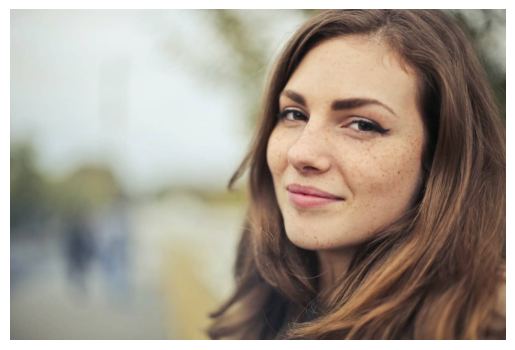

In [ ]:
# Download the image and plotting it
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/person-1.jpg',
    os.path.join(inference_dir, 'person.jpg')
)

img = Image.open(os.path.join(inference_dir, 'person.jpg'))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# Running inference on the image
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img)
with torch.no_grad():
    pred = model([img_tensor])

In [ ]:
# Lets look at what the `pred` looks like.
# `pred` is a list of dictionaries, since we had passed a single image, we will get a single-item list
pred[0]

{'boxes': tensor([[ 431.6028,    2.4547, 1280.0001,  851.2910],
         [ 119.3285,   43.6910,  862.8621,  853.0000]]),
 'labels': tensor([1, 1]),
 'scores': tensor([0.9998, 0.1074]),
 'masks': tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0013, 0.0013, 0.0012],
           [0.0000, 0.0000, 0.0000,  ..., 0.0014, 0.0014, 0.0013],
           [0.0000, 0.0000, 0.0000,  ..., 0.0015, 0.0015, 0.0014],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.1385, 0.1310, 0.1234],
           [0.0000, 0.0000, 0.0000,  ..., 0.1301, 0.1230, 0.1159],
           [0.0000, 0.0000, 0.0000,  ..., 0.1216, 0.1150, 0.1083]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0

In [ ]:
# We will keep only the pixels with values  greater than 0.5 as 1, and set the rest to 0.
masks = (pred[0]['masks']>0.5).squeeze().detach().cpu().numpy()
masks.shape

(2, 853, 1280)

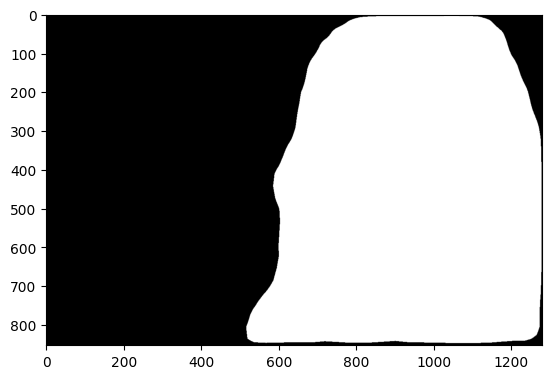

In [ ]:
# Let's plot the mask for the `person` class since the 0th mask belongs to `person`
plt.imshow(masks[0], cmap='gray')
plt.show()

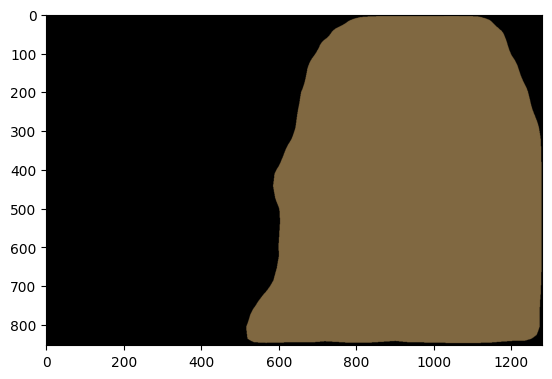

In [ ]:
# Let's color the `person` mask using the `random_color_masks` function
mask1 = random_color_masks(masks[0], COLORS)
plt.imshow(mask1)
plt.show()

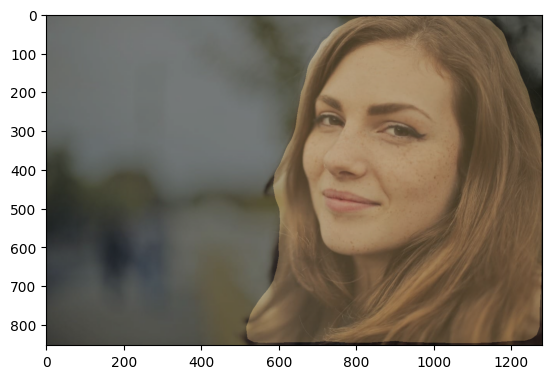

In [ ]:
# Let's blend the original and the masked image and plot it.
blend_img = cv2.addWeighted(np.asarray(img), 0.5, mask1, 0.5, 0)

plt.imshow(blend_img)
plt.show()

### 3.2. Instance Segmentation on Persons

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn_standing_people.jpg',
    os.path.join(inference_dir, 'mrcnn_standing_people.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn_standing_people.jpg'), 0.75)

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


### 3.3. Instance Segmentation on Cars

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn_cars-scaled.jpg',
    os.path.join(inference_dir, 'mrcnn_cars.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn_cars.jpg'), 0.9)

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


### 3.4. Instance Segmentation on Traffic Scene

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn-traffic.jpg',
    os.path.join(inference_dir, 'mrcnn-traffic.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn-traffic.jpg'), 0.6)

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


### 3.5. Instance Segmentation on Birds

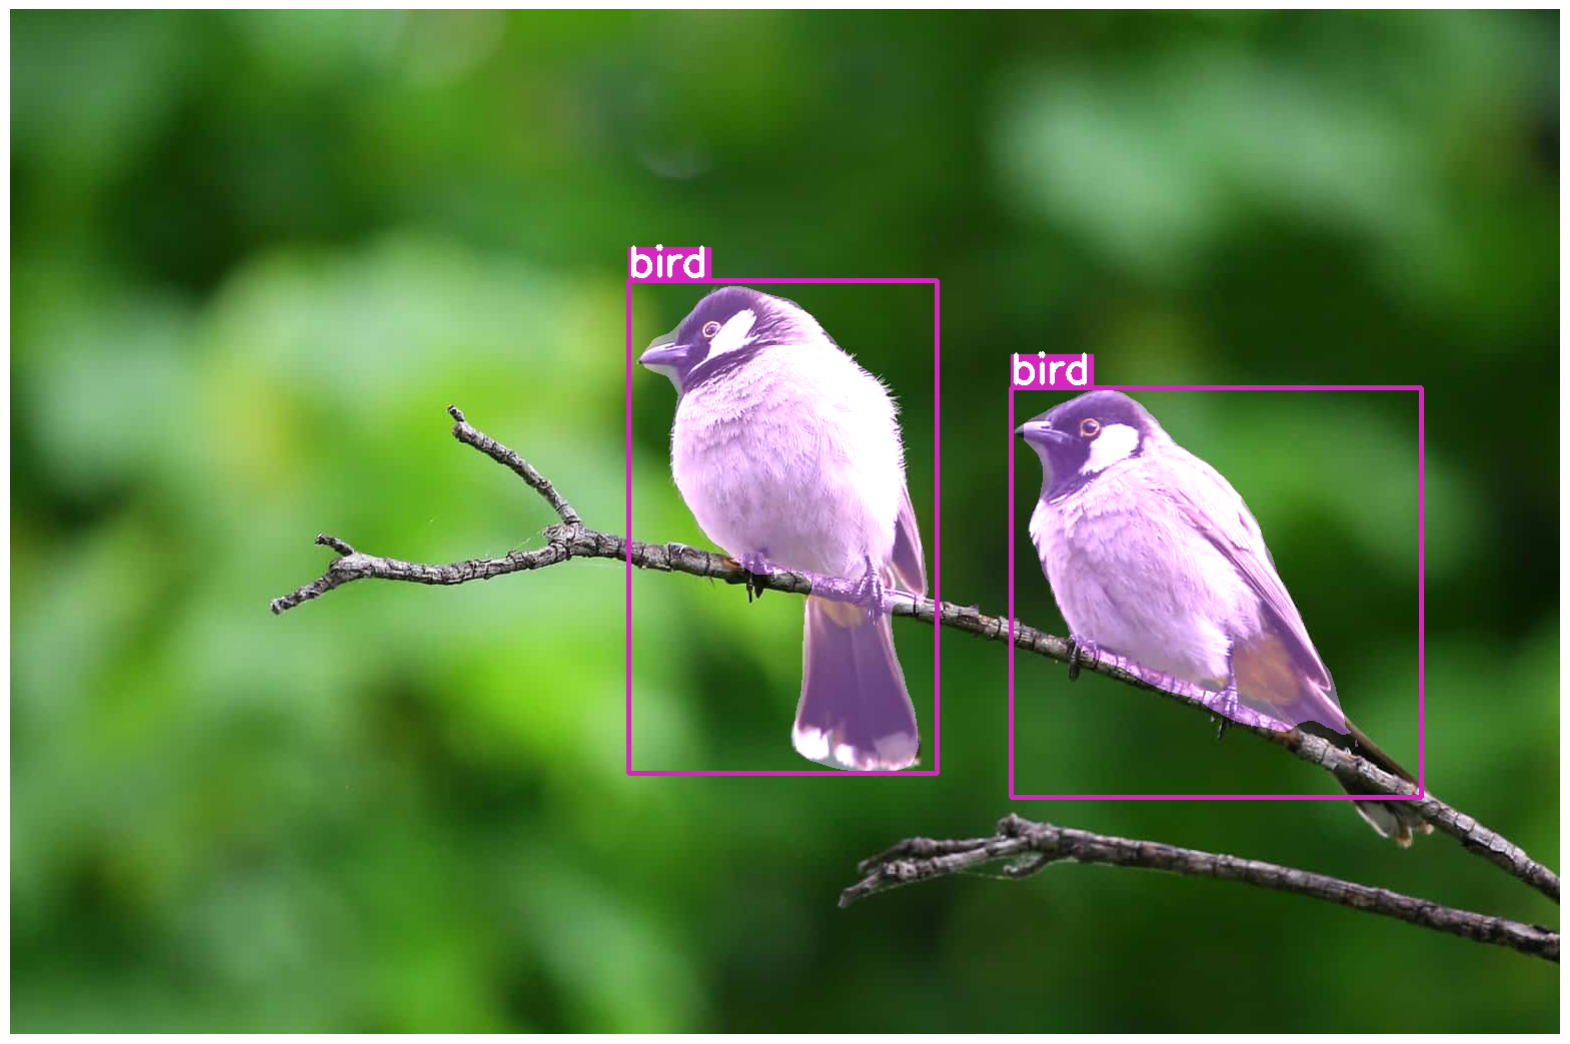

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn-birds.jpg',
    os.path.join(inference_dir, 'mrcnn-birds.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn-birds.jpg'), 0.9)

### 3.6. Instance Segmentation on Crowded Image

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn-crowd.jpg',
    os.path.join(inference_dir, 'mrcnn-crowd.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn-crowd.jpg'), 0.8)

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


### 3.7. Instance Segmentation on Animals

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn-horses.jpg',
    os.path.join(inference_dir, 'mrcnn-horses.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn-horses.jpg'), 0.8)

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


### 3.8. Instance Segmentation in Low Light Condition

In [ ]:
download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/mrcnn-low-light.jpg',
    os.path.join(inference_dir, 'mrcnn-low-light.jpg')
)
instance_segmentation_api(os.path.join(inference_dir, 'mrcnn-low-light.jpg'), 0.8)

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


# 4. Comparing the inference time of model in CPU & GPU



In [ ]:
# Load model
model = torchvision.models.detection.maskrcnn_resnet50_fpn(
    weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT
)
# Set model on evalution mode
model.eval()

import time

def check_inference_time(image_path, gpu=False):
    """
    Measures the inference time of a model on a given image.

    Parameters:
        image_path (str): Path to the input image.
        gpu (bool, optional): Whether to run inference on GPU. Defaults to False.

    Returns:
        float: Time taken for model inference in seconds.
    """

    # Load image and convert to a PyTorch tensor
    img = T.ToTensor()(Image.open(image_path)).unsqueeze(0)  # Add batch dimension

    # Move model and image to the selected device
    device = torch.device("cuda:0" if gpu and torch.cuda.is_available() else "cpu")
    model.to(device)
    img = img.to(device)

    # Measure inference time
    start_time = time.time()
    with torch.no_grad():  # Disable gradient tracking for faster inference
        model(img)
    return time.time() - start_time  # Return elapsed time


In [ ]:
# Let's run inference on all the downloaded images and average their inference time
img_paths = [
    path for path in glob.glob(os.path.join(inference_dir, '*')) \
    if path.split('.')[-1].lower() in ["jpeg", "jpg", "png"]
]

gpu_times = []
for img_path in img_paths:
    gpu_time = check_inference_time(img_path, gpu=True)
    gpu_times.append(gpu_time)

gpu_time = sum([check_inference_time(img_path, gpu=True) for img_path in img_paths])/len(img_paths)
cpu_time = sum([check_inference_time(img_path, gpu=False) for img_path in img_paths])/len(img_paths)

print('\n\nAverage Time take by the model with GPU = {}s\nAverage Time take by the model with CPU = {}s'.format(gpu_time, cpu_time))



Average Time take by the model with GPU = 0.14972665574815539s
Average Time take by the model with CPU = 6.438831726710002s


#5. Application: Background blurring

Here we will use the segmentation algorithm to blur the background. The whole concept is broken down into few steps.  
1. Pick the class we want to keep as foreground (person) and get its mask using the segmentation api. The locations belonging to person-class will be labelled as 1 and the rest as 0.
2. Blur the original image.
3. Create a new image such that, pixel locations where the mask is 1 is replaced with the original values and the rest with the blurred values.

Following is the code.

In [ ]:
def pick_person_mask(img_path, threshold=0.5, rect_th=3, text_size=3, text_th=3):
    # get the predicted masks and boxes and their corresponding labels
    masks, boxes, pred_cls = get_prediction(img_path, threshold)
    # pick the indices belonging to person
    person_ids = [i for i in range(len(pred_cls)) if pred_cls[i]=="person"]
    # pick the masks with the person-ids
    person_masks = masks[person_ids, :, :]
    # create a single mask out of all the instances and clip them
    persons_mask = person_masks.sum(axis=0)
    persons_mask = np.clip(persons_mask, 0,1)
    return persons_mask

In [ ]:
# These are a few images you can play around with

# https://cdn.pixabay.com/photo/2018/03/12/20/57/woman-3220835_1280.jpg
# https://cdn.pixabay.com/photo/2017/02/06/10/54/sad-2042536_1280.jpg
# https://cdn.pixabay.com/photo/2016/11/29/09/49/blond-1868815_1280.jpg
# https://cdn.pixabay.com/photo/2017/03/27/14/56/auto-2179220_1280.jpg
# https://cdn.pixabay.com/photo/2017/03/27/14/56/auto-2179220_1280.jpg

download_file(
    'https://learnopencv.com/wp-content/uploads/2022/10/person_blur.jpg',
    inference_dir + '/person_blur.jpg'
)

# grab the image and blur it
img_path = inference_dir + '/person_blur.jpg'
img = cv2.imread(img_path)
img_blur = cv2.GaussianBlur(img, (21, 21), 0)

# create the person-mask
person_mask = pick_person_mask(img_path, threshold=0.5, rect_th=3, text_size=3, text_th=3).astype(np.uint8)
person_mask = np.repeat(person_mask[:, :, None], 3, axis=2)

# finally, create a new image such that pixels where the mask=1, replace it with original image and keep the rest of the pixels
# with blurred image
final_img = np.where(person_mask==1, img, img_blur)

plt.figure(figsize=(15, 12))
# plt.subplot(121)
plt.imshow(img[:,:,::-1])
plt.title('Original Image')
plt.axis('off')
plt.show()
# plt.subplot(122)
plt.figure(figsize=(15, 12))
plt.imshow(final_img[:,:,::-1])
plt.title('Image with blurred background')
plt.axis('off')
plt.show()

Dane wyjściowe tej komórki są za duże i można je wyświetlić tylko po zalogowaniu się.


# 6. Conclusion

Instance Segmentation is challenging because it requires the correct detection of all objects in an image while also precisely segmenting each instance. It therefore combines elements from the classical computer vision tasks of object detection, where the goal is to classify individual objects and localize each using a bounding box, and semantic segmentation, where the goal is to classify each pixel into a fixed set of categories without differentiating object instances.

One of the significant challenges in instance segmentation is dealing with occlusions, especially when objects of the same class overlap. Despite this, our Mask R-CNN model performed exceptionally well across all instances,

We have seen some cool visuals and at the end an interesting blurring application.

